In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [24]:
# -------------------------------
# Scikit-Learn (Machine Learning utilities)
# -------------------------------
from sklearn.model_selection import train_test_split
#  Splits the dataset into training and testing sets to evaluate model performance.

from sklearn.preprocessing import LabelEncoder, StandardScaler
# LabelEncoder: Converts categorical labels (e.g., "cat", "dog") into numeric values.
# StandardScaler: Normalizes/standardizes numerical features so they have mean=0 and variance=1.

from sklearn.linear_model import Perceptron
# A simple linear classifier (single-layer neural network). Good for binary classification tasks.

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# accuracy_score: Measures how many predictions are correct.
# classification_report: Shows precision, recall, and F1-score for each class.
# confusion_matrix: Shows where the model is making correct vs wrong predictions.

# -------------------------------
# TensorFlow / Keras (Deep Learning utilities)
# -------------------------------
import tensorflow as tf

from tensorflow.keras.models import Sequential
# Lets you build a neural network layer-by-layer in a linear fashion.

from tensorflow.keras.layers import Dense
# Fully connected layer (every neuron connects to every neuron in the next layer).

from tensorflow.keras.layers import Dropout
# Randomly drops some neurons during training to prevent overfitting.

from tensorflow.keras.utils import to_categorical
# 👉 Converts class labels (like 0, 1, 2) into one-hot encoded format (e.g., [1,0,0], [0,1,0])

In [25]:
df = sns.load_dataset('iris')

In [26]:
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [27]:
df.rename(columns={
    'sepal_length': 'SepalLengthCm',
    'sepal_width': 'SepalWidthCm',
    'petal_length':'PetalLengthCm',
    'petal_width' : 'PetalWidthCm',
    'species' : 'Species'
}, inplace=True)

In [28]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


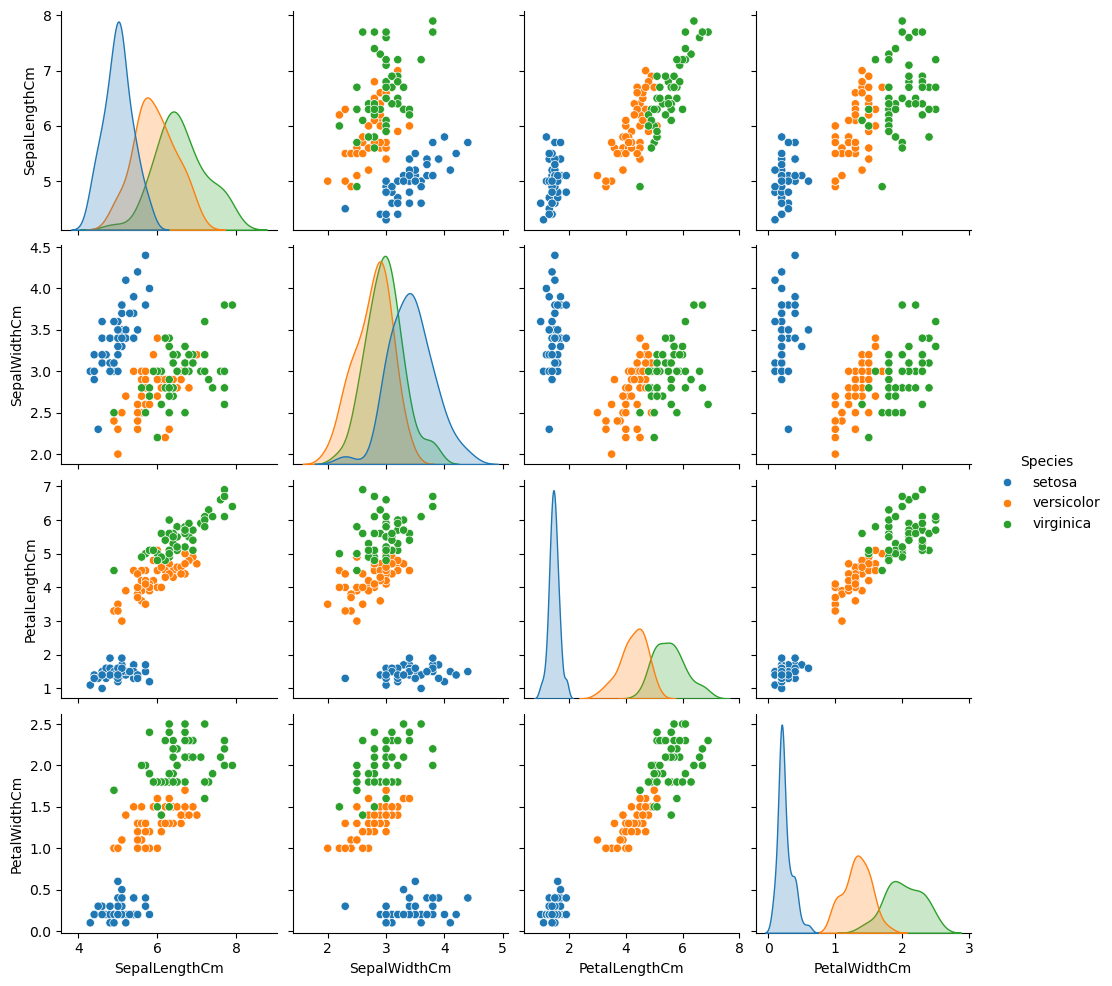

In [29]:
sns.pairplot(df,hue="Species")

In [30]:
X = df.drop("Species", axis=1)
y = df['Species']

In [31]:
encoder = LabelEncoder()
y_int = encoder.fit_transform(y)

In [32]:
X_train, X_test, y_train, y_test= train_test_split(X, y_int, test_size=0.2,random_state=42, stratify=y_int)

In [33]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [34]:
per = Perceptron(max_iter = 1000,random_state=42)
per.fit(X_train_scaled,y_train)

,penalty,None
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,eta0,1.0
,n_jobs,None
,random_state,42


In [35]:
y_pred_percep = per.predict(X_test_scaled)

In [36]:
accuracy_score(y_test, y_pred_percep)

0.9

In [37]:
# ANN
y_train_cat = to_categorical(y_train, num_classes =3)
y_test_cat = to_categorical(y_test, num_classes =3)

In [43]:
model = Sequential([
    Dense(16,input_dim = 4, activation='relu'),
    Dense(8,activation='relu'),
    Dense(3,activation='softmax'),
])

In [44]:
model.compile(optimizer = "adam", loss = "categorical_crossentropy" , metrics = ["accuracy"])

In [45]:
history = model.fit(
    X_train_scaled, y_train_cat, 
    epochs = 100, batch_size = 8, 
    validation_split=0.2, verbose = 1)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.4688 - loss: 1.0347 - val_accuracy: 0.4167 - val_loss: 1.0715
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5729 - loss: 1.0017 - val_accuracy: 0.4583 - val_loss: 1.0427
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6354 - loss: 0.9736 - val_accuracy: 0.5000 - val_loss: 1.0168
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6667 - loss: 0.9459 - val_accuracy: 0.5000 - val_loss: 0.9933
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6667 - loss: 0.9198 - val_accuracy: 0.5833 - val_loss: 0.9695
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6771 - loss: 0.8902 - val_accuracy: 0.5833 - val_loss: 0.9475
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6771 - loss: 0.8636 - val_accuracy: 0.5833 - val_loss: 0.9253
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6771 - loss: 0.8359 - val_accuracy: 0.

In [46]:
loss, acc = model.evaluate(X_test_scaled, y_test_cat, verbose=1)
print(acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.9333 - loss: 0.2190
0.9333333373069763


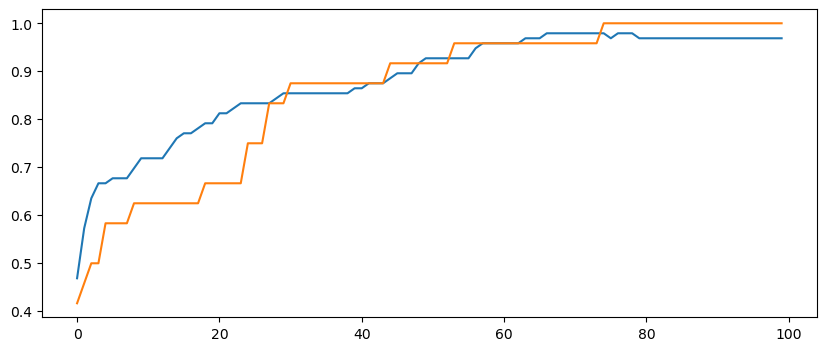

In [47]:
plt.figure(figsize = (10,4))
plt.plot(history.history['accuracy'],label = "train Acc")
plt.plot(history.history['val_accuracy'],label = "val Acc")